# Notebook 05 — Late Delivery Risk Prediction
**Tujuan:** Model prediksi risiko keterlambatan sebelum order dikirim (Logistic Regression vs Random Forest).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

OUT     = Path('../output')
FIGURES = OUT / 'figures'

BLUE  = '#2563EB'
RED   = '#DC2626'
LIGHT = '#93C5FD'
GRAY  = '#6B7280'

df = pd.read_parquet(OUT / 'df_clean.parquet')
print(f'Loaded: {len(df):,} | Late rate: {df["is_late"].mean():.1%}')

Loaded: 180,519 | Late rate: 54.8%


## 1. Feature Selection & Preprocessing

In [2]:
qty_col    = [c for c in df.columns if 'order_item_quantity' in c or ('quantity' in c and 'order' in c)][0]
benefit_col= [c for c in df.columns if 'benefit_per_order' in c or 'benefit' in c][0]

# Top 10 kategori
top_cats = df['category_name'].value_counts().head(10).index.tolist()
df['category_top'] = df['category_name'].where(df['category_name'].isin(top_cats), 'Other')

feature_cols = ['shipping_mode', 'market', 'category_top',
                qty_col, benefit_col, 'scheduled_lead_time']
target_col   = 'is_late'

df_model = df[feature_cols + [target_col]].dropna().copy()
X = pd.get_dummies(df_model[feature_cols], drop_first=True)
y = df_model[target_col]

num_cols = [c for c in [qty_col, benefit_col, 'scheduled_lead_time'] if c in X.columns]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {X.shape[1]}')

Train: 144,415 | Test: 36,104 | Features: 20


## 2. Logistic Regression (Baseline)

In [3]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['On Time','Late']))
print(f'AUC: {auc_lr:.4f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

     On Time       0.61      0.88      0.72     16308
        Late       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

AUC: 0.7283


## 3. Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['On Time','Late']))
print(f'AUC: {auc_rf:.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

     On Time       0.58      0.60      0.59     16308
        Late       0.66      0.64      0.65     19796

    accuracy                           0.62     36104
   macro avg       0.62      0.62      0.62     36104
weighted avg       0.62      0.62      0.62     36104

AUC: 0.6812


## 4. Evaluasi Visual

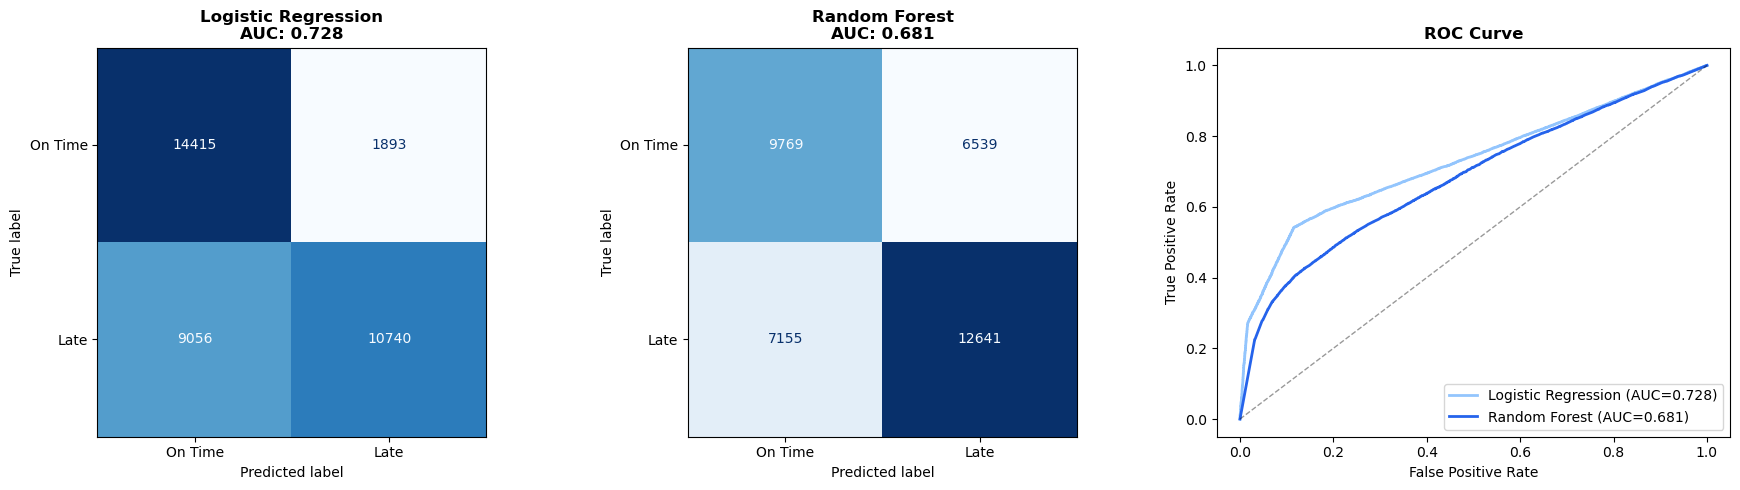

Saved: H_model_evaluation.png


In [5]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['On Time','Late']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAUC: {auc_lr:.3f}', fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['On Time','Late']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Random Forest\nAUC: {auc_rf:.3f}', fontweight='bold')

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, LIGHT),
    ('Random Forest',       y_prob_rf, BLUE)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[2].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
axes[2].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES / 'H_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: H_model_evaluation.png')

## 5. Feature Importance & Simpan Hasil

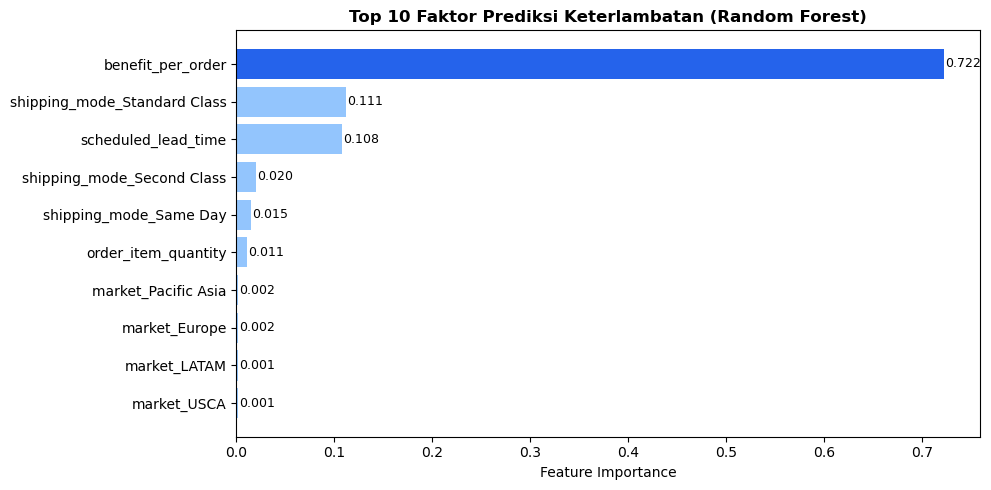

Saved: I_feature_importance.png

Saved: model_results.json
RF AUC: 0.6812 | At-risk orders: 94,138


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_fi = [BLUE if i == len(feat_imp)-1 else LIGHT for i in range(len(feat_imp))]
ax.barh(feat_imp.index, feat_imp.values, color=colors_fi)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Faktor Prediksi Keterlambatan (Random Forest)', fontweight='bold')
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'I_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: I_feature_importance.png')

# Estimasi business impact
at_risk_orders = int((rf.predict(X) == 1).sum())

results = {
    'logistic_regression': {
        'auc':       round(auc_lr, 4),
        'precision': round(precision_score(y_test, y_pred_lr), 4),
        'recall':    round(recall_score(y_test, y_pred_lr), 4),
        'f1':        round(f1_score(y_test, y_pred_lr), 4)
    },
    'random_forest': {
        'auc':       round(auc_rf, 4),
        'precision': round(precision_score(y_test, y_pred_rf), 4),
        'recall':    round(recall_score(y_test, y_pred_rf), 4),
        'f1':        round(f1_score(y_test, y_pred_rf), 4)
    },
    'business_impact': {
        'at_risk_orders': at_risk_orders,
        'late_rate_dataset': round(float(df['is_late'].mean()), 4)
    },
    'feature_importance_top10': feat_imp[::-1].to_dict()
}

with open(OUT / 'model_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved: model_results.json')
print(f'RF AUC: {auc_rf:.4f} | At-risk orders: {at_risk_orders:,}')